In [1]:
!pip install pandas matplotlib numpy

Access is denied.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

os.makedirs('charts', exist_ok=True)
os.makedirs('output', exist_ok=True)
print('✅ Setup complete')


✅ Setup complete


In [20]:
import pandas as pd

df = pd.read_excel(r'C:\Users\Dell\Downloads\sales_analysis\data\sales_1000_products.xlsx')
print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')

df.head()

Shape   : (1000, 10)
Columns : ['ProductID', 'ProductName', 'Description', 'Price', 'Quantity', 'Discount(%)', 'GST(%)', 'TotalBeforeGST', 'GSTAmount', 'GrossAmount']


,ProductID,ProductName,Description,Price,Quantity,Discount(%),GST(%),TotalBeforeGST,GSTAmount,GrossAmount
0,P0001,Tablet,Tablet product description,1642.84,79,0,18,129784.36,23361.18,153145.54
1,P0002,Laptop,Laptop product description,1476.67,65,10,18,86385.20,15549.34,101934.53
2,P0003,Mouse,Mouse product description,2669.50,67,0,18,178856.50,32194.17,211050.67
3,P0004,Notebook,Notebook product description,3852.35,17,10,18,58940.96,10609.37,69550.33
4,P0005,Pen,Pen product description,2536.96,93,0,18,235937.28,42468.71,278405.99


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ProductID       1000 non-null   object 
 1   ProductName     1000 non-null   object 
 2   Description     1000 non-null   object 
 3   Price           1000 non-null   float64
 4   Quantity        1000 non-null   int64  
 5   Discount(%)     1000 non-null   int64  
 6   GST(%)          1000 non-null   int64  
 7   TotalBeforeGST  1000 non-null   float64
 8   GSTAmount       1000 non-null   float64
 9   GrossAmount     1000 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 78.3+ KB


In [22]:
df.describe().round(2)

,Price,Quantity,Discount(%),GST(%),TotalBeforeGST,GSTAmount,GrossAmount
count,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00
mean,2523.43,50.42,7.36,18.0,116927.28,21046.91,137974.19
std,1373.18,29.59,5.58,0.0,100730.59,18131.51,118862.09
min,60.68,1.00,0.00,18.0,258.47,46.52,304.99
25%,1360.42,24.00,0.00,18.0,34526.28,6214.73,40741.02
50%,2540.69,51.00,5.00,18.0,87664.56,15779.62,103444.18
75%,3665.82,75.00,10.00,18.0,182483.25,32846.98,215330.24
max,4991.19,100.00,15.00,18.0,472659.66,85078.74,557738.40


In [23]:
print('=' * 55)
print('  SALES SUMMARY')
print('=' * 55)
print(f'  Total Products       : {len(df):,}')
print(f'  Total Gross Revenue  : ₹{df["GrossAmount"].sum():,.2f}')
print(f'  Avg Unit Price       : ₹{df["Price"].mean():,.2f}')
print(f'  Avg Discount         : {df["Discount(%)"].mean():.1f}%')
print(f'  GST Rate (uniform)   : {df["GST(%)"].iloc[0]}%')
print(f'  Total GST Collected  : ₹{df["GSTAmount"].sum():,.2f}')
print('=' * 55)

  SALES SUMMARY
  Total Products       : 1,000
  Total Gross Revenue  : ₹137,974,188.81
  Avg Unit Price       : ₹2,523.43
  Avg Discount         : 7.4%
  GST Rate (uniform)   : 18%
  Total GST Collected  : ₹21,046,910.08


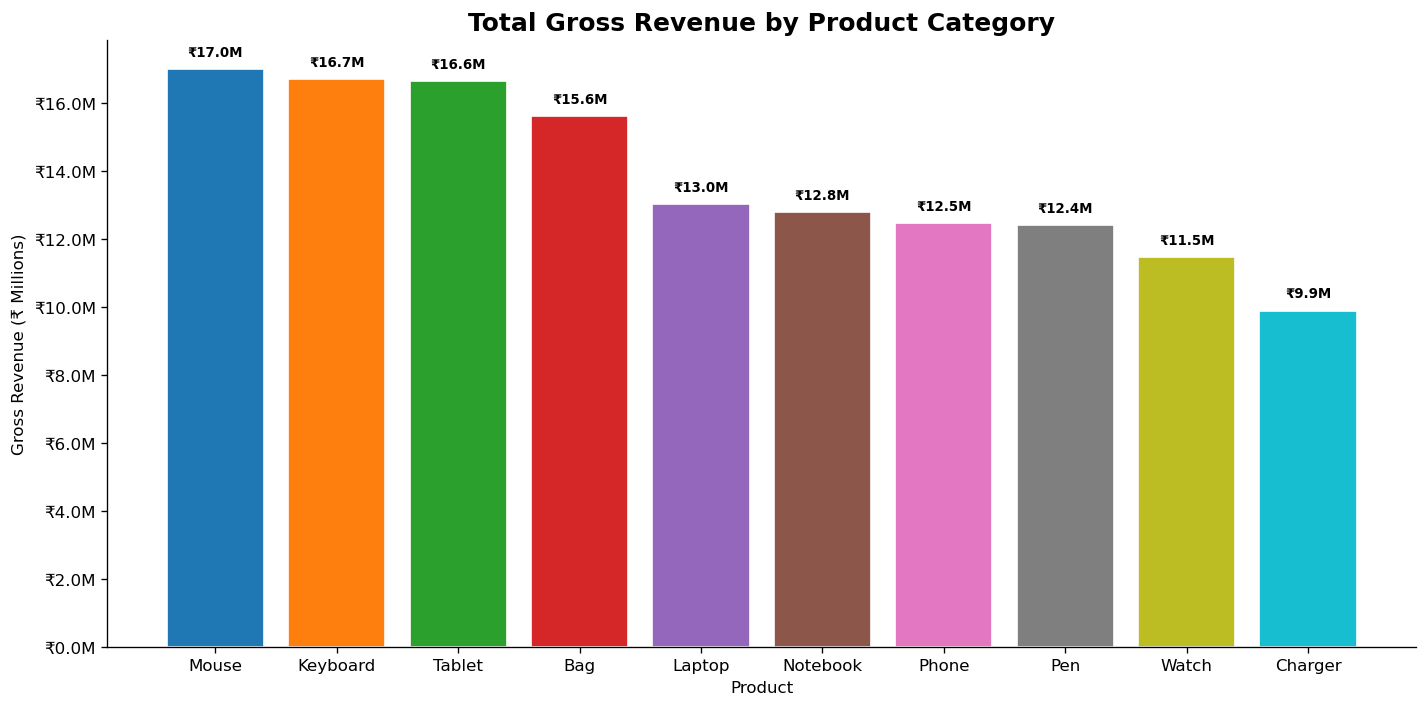

In [24]:
rev = df.groupby('ProductName')['GrossAmount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(rev.index, rev.values / 1e6, color=plt.cm.tab10.colors[:len(rev)], edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'₹{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Total Gross Revenue by Product Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Product'); ax.set_ylabel('Gross Revenue (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.1fM'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/01_revenue_by_product.png', dpi=150)
plt.show()

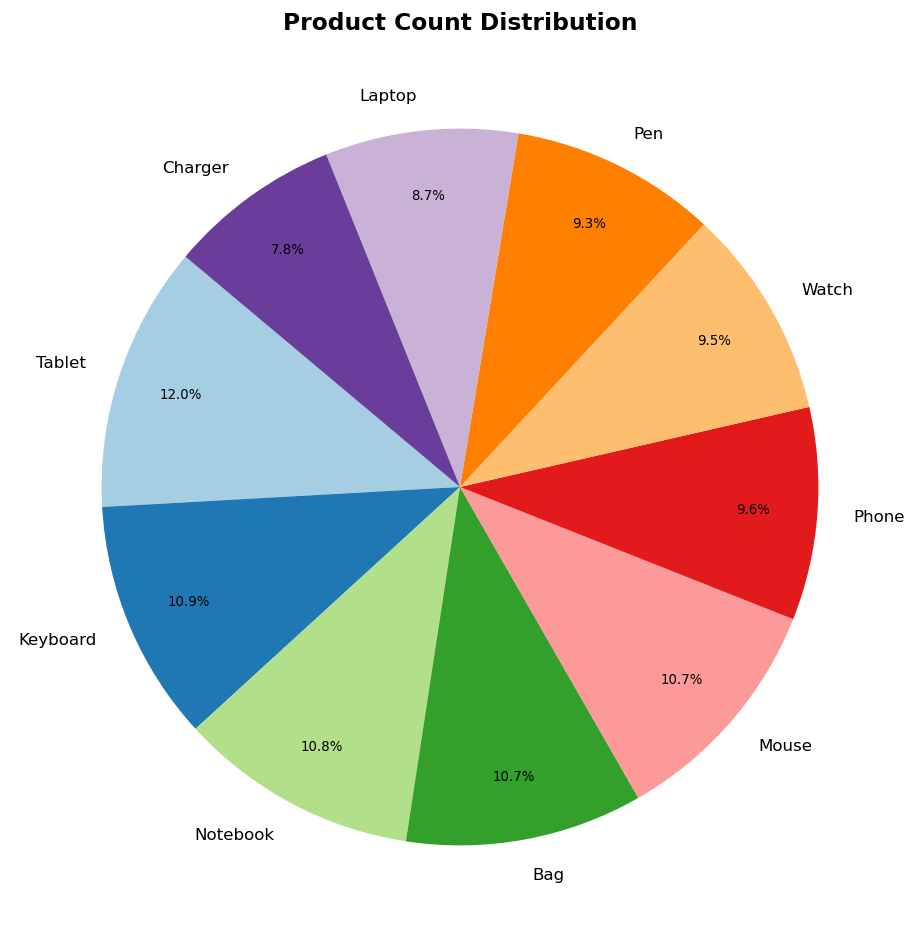

In [25]:
counts = df['ProductName'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    colors=plt.cm.Paired.colors[:len(counts)]
)
for t in autotexts:
    t.set_fontsize(8)

ax.set_title('Product Count Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_product_count_pie.png', dpi=150)
plt.show()

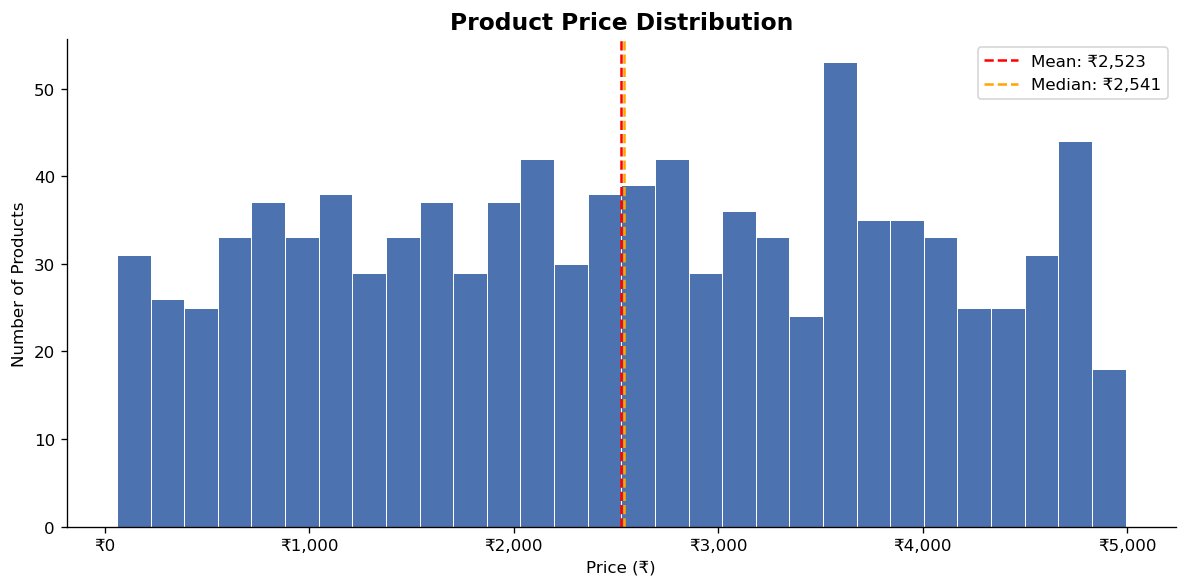

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Price'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.6)

ax.axvline(df['Price'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: ₹{df["Price"].mean():,.0f}')
ax.axvline(df['Price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ₹{df["Price"].median():,.0f}')

ax.set_title('Product Price Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (₹)'); ax.set_ylabel('Number of Products')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/03_price_histogram.png', dpi=150)
plt.show()

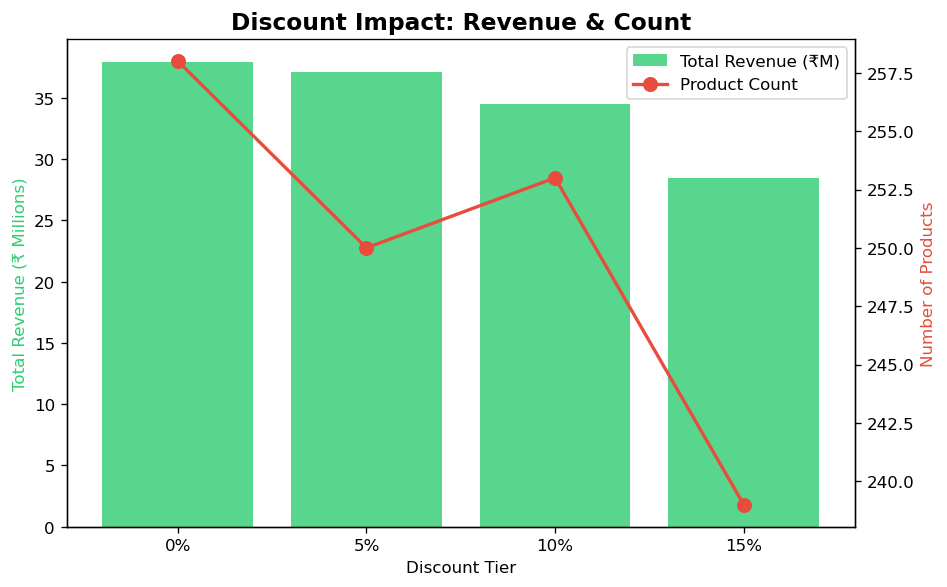

In [27]:
disc_rev = df.groupby('Discount(%)')['GrossAmount'].agg(['sum', 'count']).reset_index()
disc_rev.columns = ['Discount', 'TotalRevenue', 'Count']

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.bar(disc_rev['Discount'].astype(str) + '%', disc_rev['TotalRevenue'] / 1e6,
        color='#2ecc71', alpha=0.8, label='Total Revenue (₹M)')
ax2.plot(disc_rev['Discount'].astype(str) + '%', disc_rev['Count'],
         color='#e74c3c', marker='o', linewidth=2, markersize=8, label='Product Count')

ax1.set_title('Discount Impact: Revenue & Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Discount Tier')
ax1.set_ylabel('Total Revenue (₹ Millions)', color='#2ecc71')
ax2.set_ylabel('Number of Products', color='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/04_discount_impact.png', dpi=150)
plt.show()





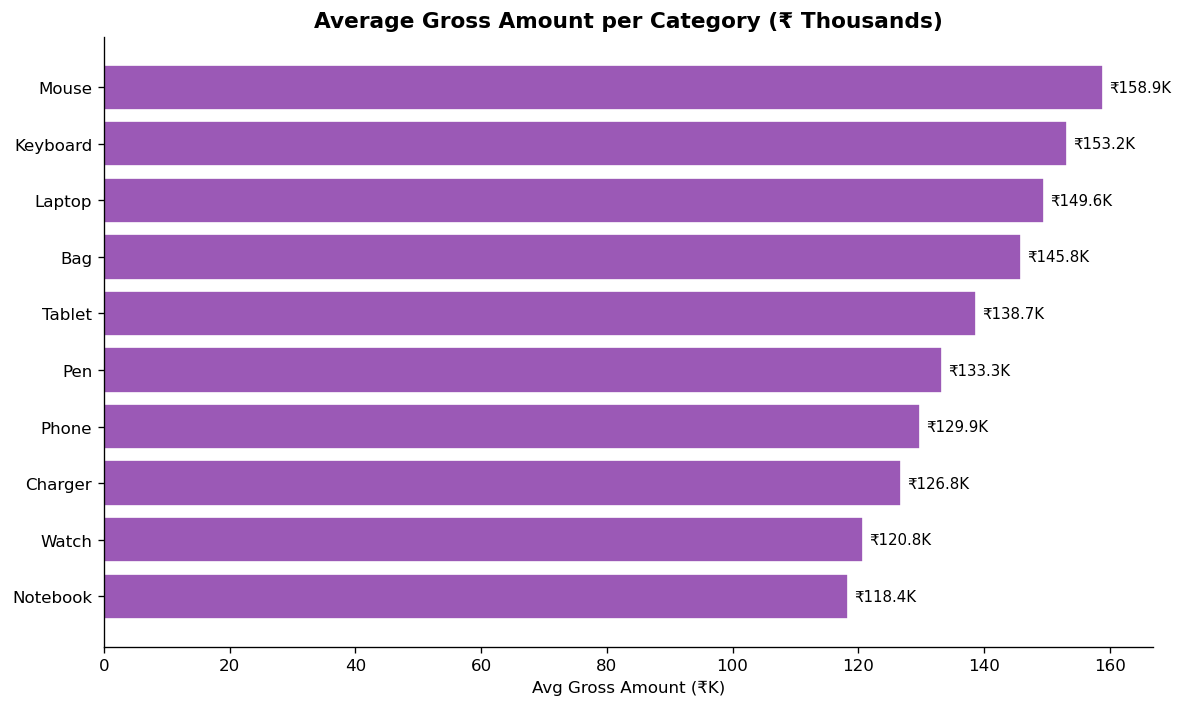

In [28]:
avg_gross = df.groupby('ProductName')['GrossAmount'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(avg_gross.index, avg_gross.values / 1e3, color='#9b59b6', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width():.1f}K', va='center', fontsize=9)

ax.set_title('Average Gross Amount per Category (₹ Thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Gross Amount (₹K)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/05_avg_gross_by_product.png', dpi=150)
plt.show()

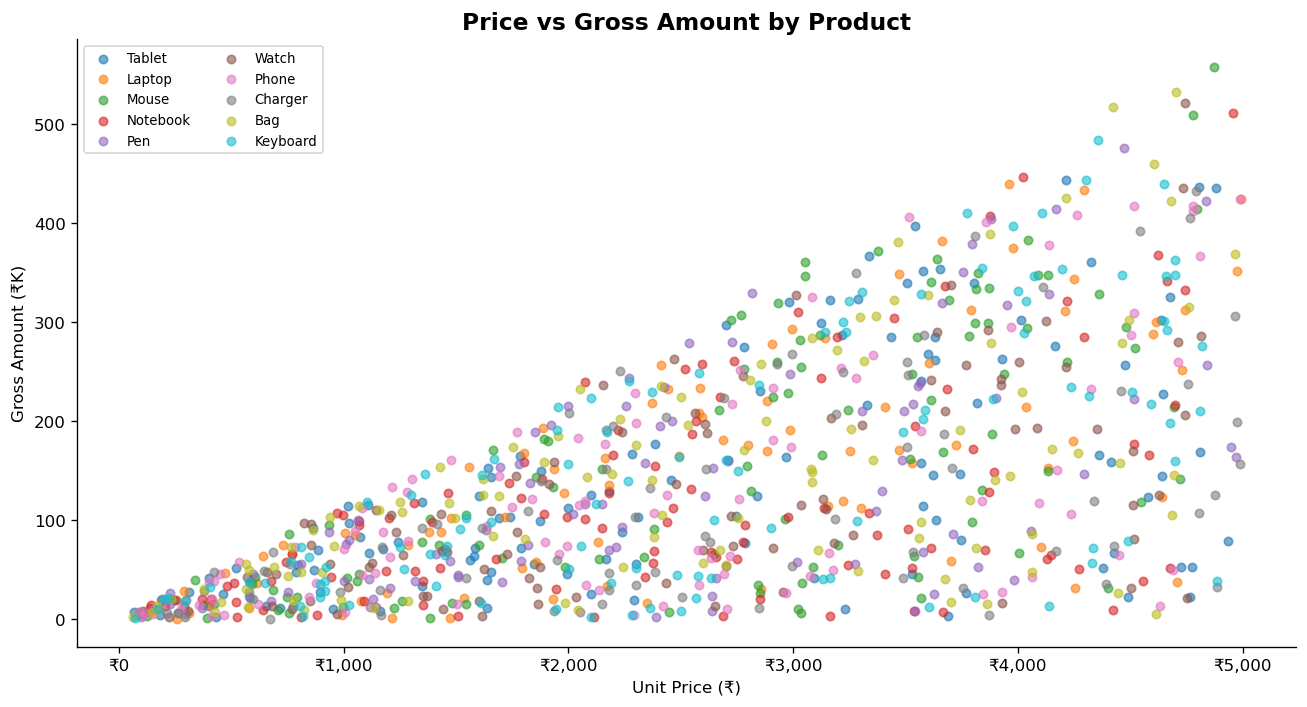

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10

for i, prod in enumerate(df['ProductName'].unique()):
    sub = df[df['ProductName'] == prod]
    ax.scatter(sub['Price'], sub['GrossAmount'] / 1e3,
               label=prod, alpha=0.6, s=25, color=cmap(i % 10))

ax.set_title('Price vs Gross Amount by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Unit Price (₹)'); ax.set_ylabel('Gross Amount (₹K)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/06_price_vs_gross_scatter.png', dpi=150)
plt.show()

In [30]:
summary_df = df.groupby('ProductName').agg(
    Count         = ('ProductID',   'count'),
    Avg_Price     = ('Price',       'mean'),
    Avg_Discount  = ('Discount(%)', 'mean'),
    Total_Revenue = ('GrossAmount', 'sum'),
    Avg_Gross     = ('GrossAmount', 'mean'),
    Total_GST     = ('GSTAmount',   'sum'),
).round(2).sort_values('Total_Revenue', ascending=False).reset_index()

summary_df

,ProductName,Count,Avg_Price,Avg_Discount,Total_Revenue,Avg_Gross,Total_GST
0,Mouse,107,2652.74,6.26,17000850.92,158886.46,2593350.18
1,Keyboard,109,2653.14,6.74,16700949.72,153219.72,2547602.50
2,Tablet,120,2562.62,8.25,16648110.25,138734.25,2539542.24
3,Bag,107,2541.16,7.34,15602361.38,145816.46,2380021.17
4,Laptop,87,2489.50,7.47,13011761.11,149560.47,1984844.91
5,Notebook,108,2459.73,8.29,12785787.63,118386.92,1950374.34
6,Phone,96,2404.25,7.19,12469028.69,129885.72,1902055.24
7,Pen,93,2407.06,7.10,12395678.42,133286.86,1890866.20
8,Watch,95,2405.81,7.53,11472788.53,120766.20,1750086.37
9,Charger,78,2634.91,7.37,9886872.16,126754.77,1508166.93


In [31]:
summary_df.to_csv('output/product_summary.csv', index=False)
print('✅ CSV saved → output/product_summary.csv')


✅ CSV saved → output/product_summary.csv
